## 1- Sentetik Veri ile EDA.
### Öncelikle kendi sentetik verimizi oluşturalım. Bir okulda 40 öğrencinin notlarına ulaştığımız varsayımı ile yaratacağız.

In [31]:
#Rassal veri üretebilmek için random
#Verisetleri düzerinde çalışacağımız için pandas
#Matematiksel işlem yapılacağı için numpy import ediyoruz
#Görselleştirme için de Pyplot ve Seaborn
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

#Öncelikle her öğrenci için özgün numara yaratıyoruz.
#Python 0 indeksli olduğu için 100-140 aralığı daha kolaylık sağlar
ogrenci_no = np.arange(100, 140)

#İlk quiz notu diğerlerinin baz alındığı korelasyon yaratıcı değişkenimiz
#Sonuçlar float gelmesin diye sınırlama sonrası sonucu integer'a çeviriyoruz
quiz1 = np.random.normal(loc=65, scale=12, size=40) #Ortalama = 65, SS = 12
quiz1 = np.clip(quiz1, 0, 100).astype(int) #Sonuçların 0 ve 100'ü geçme ihtimaline karşı sınırlandırma

#Quiz notuna 15 standart sapma ekleyerek notların tümüyle rassal olmasını engelliyoruz
#Başarılı öğrenciye başlangıç noktasını yüksek, başarısıza da düşük gelecek
vize = quiz1 + np.random.normal(loc=0, scale=15, size=40)
vize = np.clip(vize, 0, 100).astype(int)

#Quiz2 için ilk ikisinin ortalamasına 10 SS ekleyerek kartopu etkisini devam ettiriyoruz
quiz2 = (quiz1 + vize) / 2 + np.random.normal(loc=0, scale=10, size=40)
quiz2 = np.clip(quiz2, 0, 100).astype(int)

#Aynı şekilde final notları da belirleniyor ve son bir SS = 15 ile verinin stokastik yapısını koruyoruz
final = (quiz1 + quiz2 + vize) / 3 + np.random.normal(loc=0, scale=15, size=40)
final = np.clip(final, 0, 100).astype(int)

#En son yıl sonu ortalaması hesaplanıyor
yilsonu = (quiz1 * 0.1) + (quiz2 * 0.1) + (vize * 0.3) + (final * 0.5)
yilsonu = yilsonu.astype(int)

In [32]:
data = {
    'ogrenci_no': ogrenci_no,
    'quiz1': quiz1,
    'quiz2': quiz2,
    'vize': vize,
    'final': final,
    'yilsonu': yilsonu
}
#DataFrame'i oluşturup, öğrenci numarasına göre sıraladıktan sonra indeksi sıfırlıyoruz.
df = pd.DataFrame(data).sort_values(by='ogrenci_no', ascending=True).reset_index(drop=True)

#Öğrenci numarasını kategorik hale getiriyoruz
df['ogrenci_no'] = df['ogrenci_no'].astype('category')

#Verinin son haline bakıyoruz
df.head()

,ogrenci_no,quiz1,quiz2,vize,final,yilsonu
0,100,77,89,89,69,77
1,101,68,44,57,60,58
2,102,66,72,76,97,85
3,103,66,72,67,92,79
4,104,74,55,66,55,60


In [33]:
#Temel istatistiklere bakıyoruz, okuma kolaylığı için ondalıklı kısmı yuvarlıyoruz
df.describe().round(1)

,quiz1,quiz2,vize,final,yilsonu
count,40.0,40.0,40.0,40.0,40.0
mean,63.2,58.6,61.1,66.2,63.2
std,10.5,15.8,19.7,21.5,17.2
min,40.0,31.0,18.0,10.0,23.0
25%,58.8,44.8,49.5,53.8,54.2
50%,64.0,57.5,64.0,65.5,62.0
75%,70.2,72.0,74.5,81.8,78.2
max,83.0,89.0,100.0,100.0,89.0


### Kendi ürettiğimiz sentetik veri olduğu için sütunlarda isim değiştirme, eksik veri kontrolü gibi adımları atlıyoruz.

In [34]:
#Sadece sayısal değerleri seçmek için ogrenci_no ayırdığımız yeni bir dataframe yaratıyoruz
df_numeric = df.drop(columns=['ogrenci_no'])
#Aykırı değer sayısını kontrol ediyoruz
for x in df_numeric.columns:
  Q1 = df_numeric[x].quantile(0.25)
  Q3 = df_numeric[x].quantile(0.75)
  IQR = Q3 - Q1
  outliers = df_numeric[(df_numeric[x] < Q1 - 1.5*IQR) | (df_numeric[x] > Q3 + 1.5*IQR)]
  print(f"Aykırı değer sayısı {x}:{outliers.shape[0]}")

Aykırı değer sayısı quiz1:2
Aykırı değer sayısı quiz2:0
Aykırı değer sayısı vize:0
Aykırı değer sayısı final:1
Aykırı değer sayısı yilsonu:0


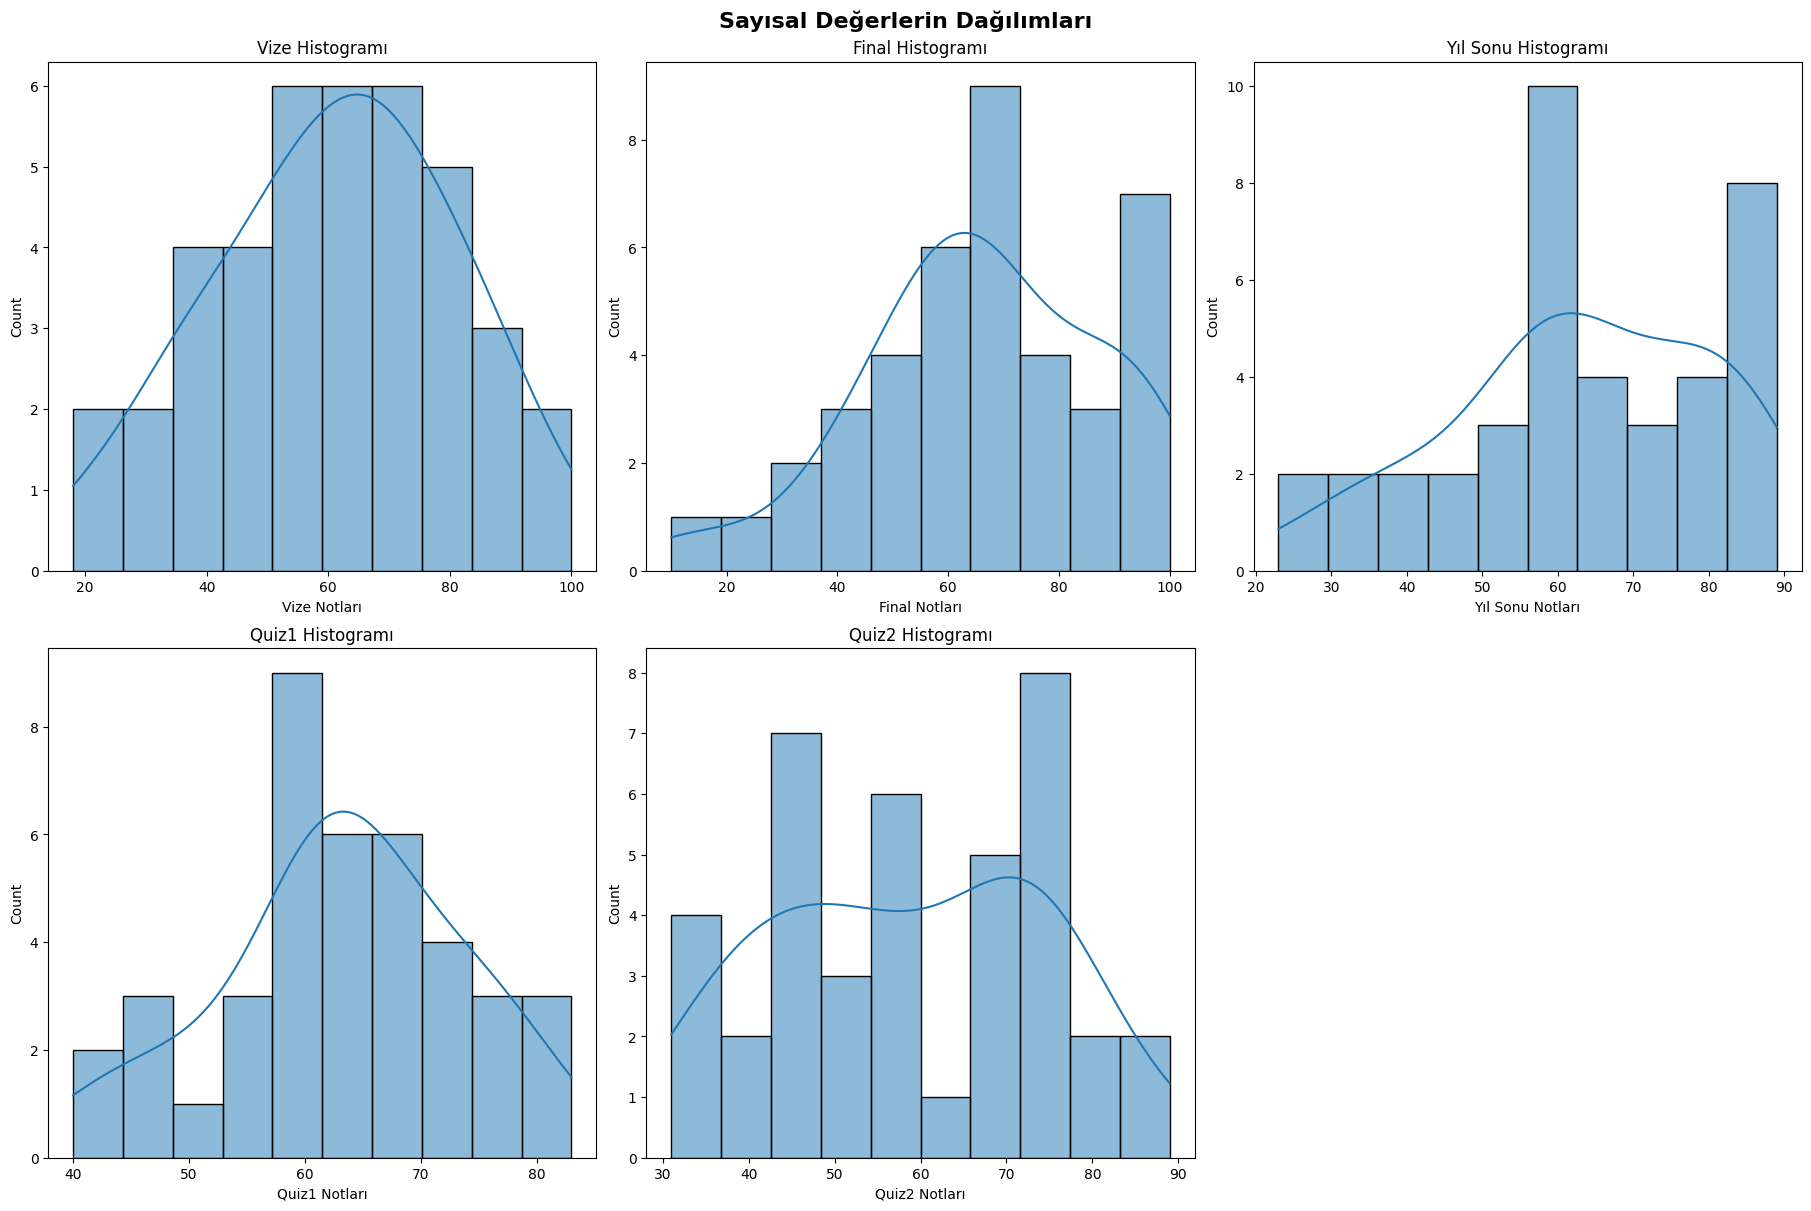

In [35]:
#Python ile Veri Görselleştirme dersinin kaynaklarından faydalanarak
#tüm histogramları tek seferde çiziyoruz
#axes'i 2 sıralı 3 sütunlu olarak belirleyip sonra grafiklere koordinat veriyoruz
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)

sns.histplot(data=df, x='vize', bins=10, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Vize Histogramı')
axes[0, 0].set_xlabel('Vize Notları')

sns.histplot(data=df, x='final', bins=10, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Final Histogramı')
axes[0, 1].set_xlabel('Final Notları')

sns.histplot(data=df, x='yilsonu', bins=10, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Yıl Sonu Histogramı')
axes[0, 2].set_xlabel('Yıl Sonu Notları')

sns.histplot(data=df, x='quiz1', bins=10, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Quiz1 Histogramı')
axes[1, 0].set_xlabel('Quiz1 Notları')

sns.histplot(data=df, x='quiz2', bins=10, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Quiz2 Histogramı')
axes[1, 1].set_xlabel('Quiz2 Notları')

#Boş grafik çizmemesi için sonuncuyu kapatıyoruz
axes[1, 2].axis('off')

fig.suptitle('Sayısal Değerlerin Dağılımları', fontsize=16, fontweight='bold')
plt.show()

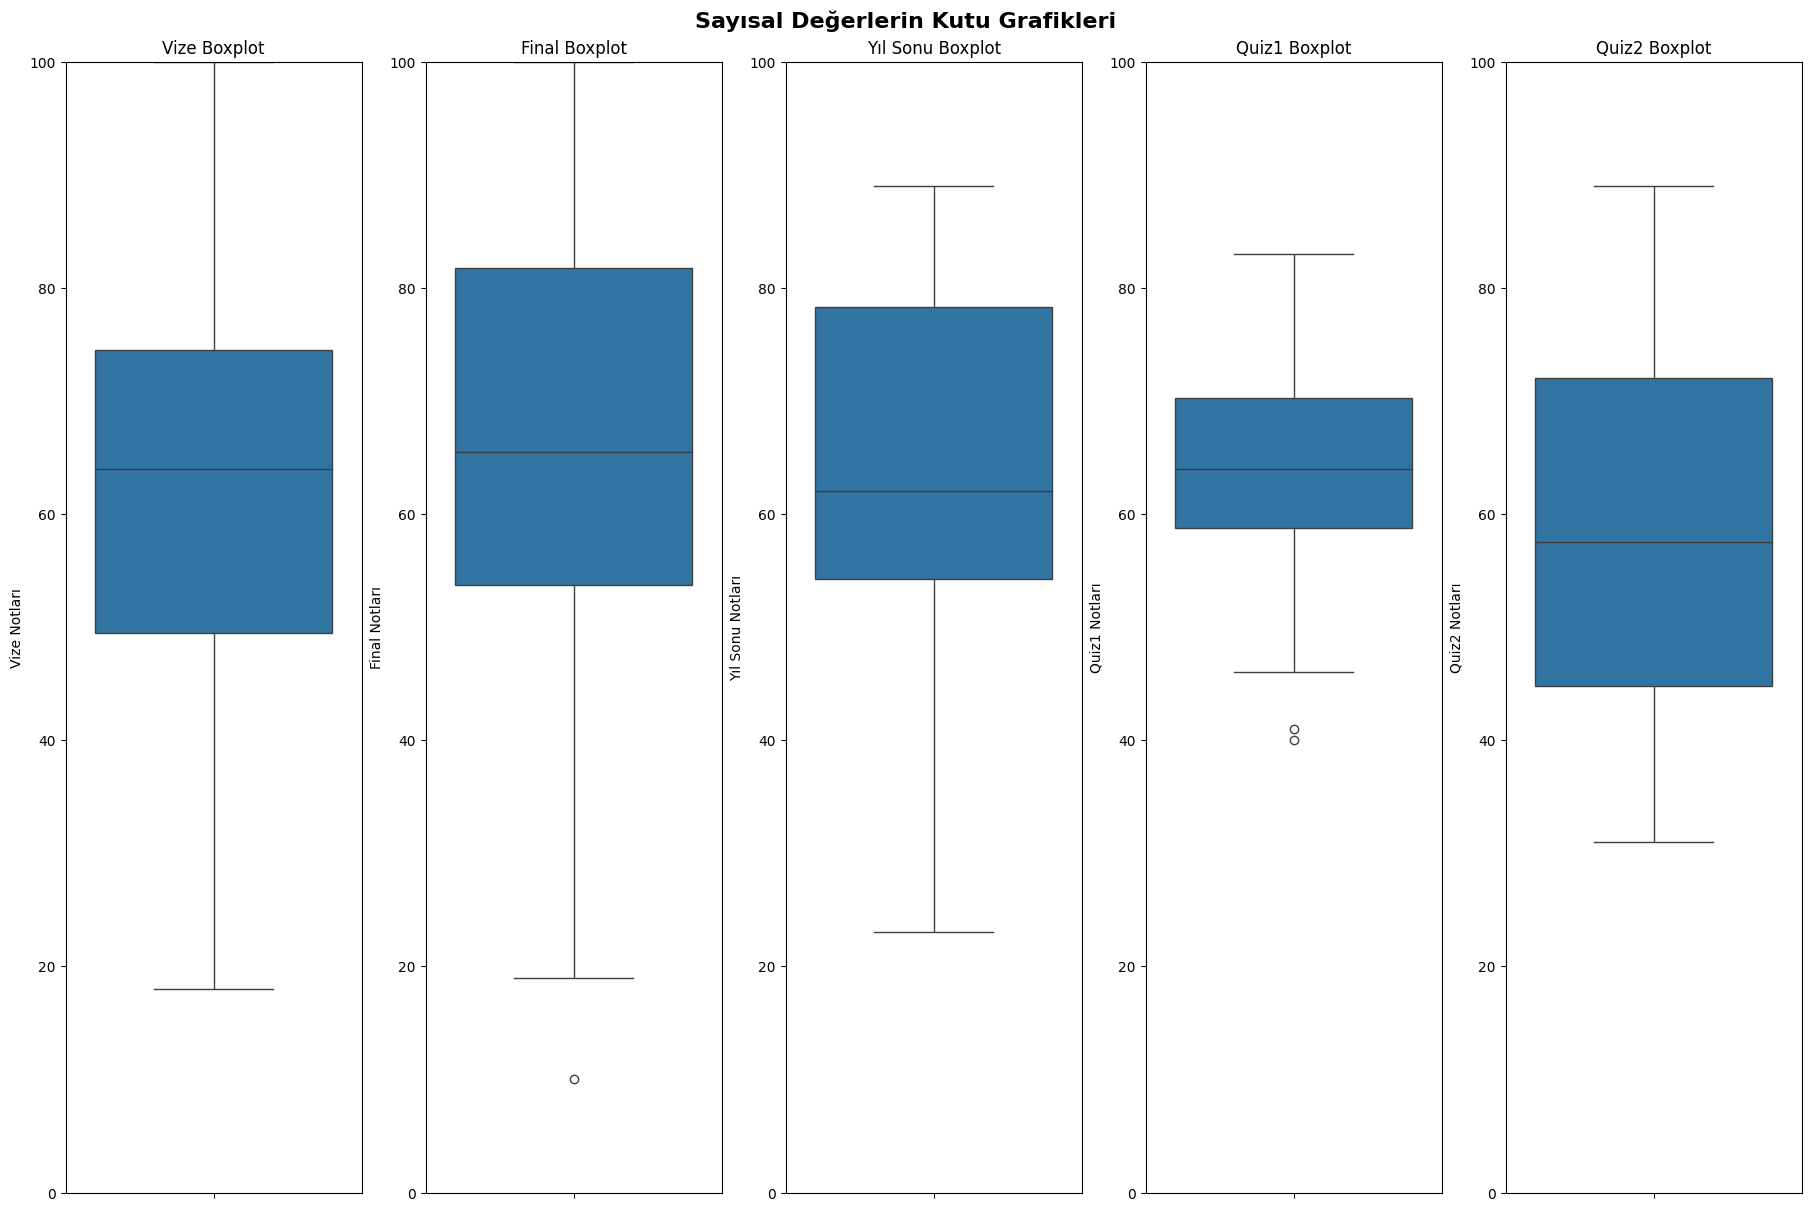

In [41]:
#Python ile Veri Görselleştirme dersinin kaynaklarından faydalanarak
#tüm boxplotları tek seferde çiziyoruz
fig, axes = plt.subplots(1, 5, figsize=(18, 12), constrained_layout=True)

sns.boxplot(data=df, y='vize', ax=axes[0])
axes[0].set_title('Vize Boxplot')
axes[0].set_ylabel('Vize Notları')
axes[0].set_ylim(0, 100)

sns.boxplot(data=df, y='final', ax=axes[1])
axes[1].set_title('Final Boxplot')
axes[1].set_ylabel('Final Notları')
axes[1].set_ylim(0, 100)

sns.boxplot(data=df, y='yilsonu', ax=axes[2])
axes[2].set_title('Yıl Sonu Boxplot')
axes[2].set_ylabel('Yıl Sonu Notları')
axes[2].set_ylim(0, 100)

sns.boxplot(data=df, y='quiz1', ax=axes[3])
axes[3].set_title('Quiz1 Boxplot')
axes[3].set_ylabel('Quiz1 Notları')
axes[3].set_ylim(0, 100)

sns.boxplot(data=df, y='quiz2', ax=axes[4])
axes[4].set_title('Quiz2 Boxplot')
axes[4].set_ylabel('Quiz2 Notları')
axes[4].set_ylim(0, 100)

fig.suptitle('Sayısal Değerlerin Kutu Grafikleri', fontsize=16, fontweight='bold')
plt.show()

In [44]:
#Görsel ile yetinmeyip Çarpıklık ve Basıklık değerlerinin kontrolünü yapıyoruz
for i in df_numeric.columns:
  print(f'Çarpıklık {i}: {df_numeric[i].skew()}, Basıklık {i}: {df_numeric[i].kurt()}')

Çarpıklık quiz1: -0.32323531396185373, Basıklık quiz1: -0.19021526763918883
Çarpıklık quiz2: -0.039328027926290844, Basıklık quiz2: -1.1233085498142965
Çarpıklık vize: -0.21003603804257584, Basıklık vize: -0.4684332809767402
Çarpıklık final: -0.4326842059241325, Basıklık final: 0.09285841806096906
Çarpıklık yilsonu: -0.4511293343900615, Basıklık yilsonu: -0.5069223744513094


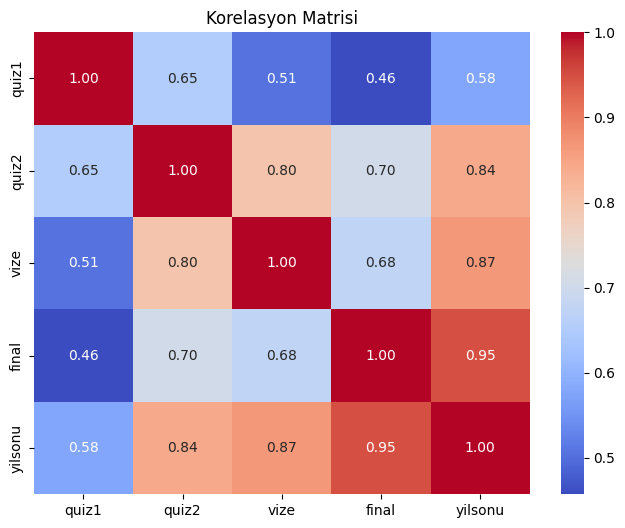

In [37]:
#Korelasyon matrisi çiziyoruz
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasyon Matrisi')
plt.show()

In [39]:
#Değişkenler arası çok yüksek korelasyon görüldüğü için multicollinearity testi ile VIF skoruna bakıyoruz
#Bu testi derste python üzerinden görmediğimiz için GenAI yardımı ile yapıyoruz

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

#ogrenci_no kategorik değişken, yilsonu'da bağımlı değişken olduğu için çıkarıp yeni dataframe hazırlıyoruz
X = df[['quiz1', 'quiz2', 'vize', 'final']]

#VIF hesaplanması için bir sabit ekliyoruz
X = add_constant(X)

#Her bağımsız değişken için VIF skorlarını for loop içerisinde hesaplıyoruz
vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

#const sırasını gerçek bir bağımsız değişken olmadığı için çıkarıyoruz
vif_data = vif_data.drop(vif_data[vif_data['variable'] == 'const'].index)

#Sonuçları yazdırıyoruz
print("Multicollinearity Testi (VIF Skorları):")
print(vif_data.round(2))

Multicollinearity Testi (VIF Skorları):
  variable   VIF
1    quiz1  1.73
2    quiz2  3.96
3     vize  2.95
4    final  2.13


### Verilerin hepsi ders notu (0-100) düzeyinde olduğu için ölçeklemeye ihtiyaç duymadan ilerliyoruz.

### Kategorik değer olarak da sadece öğrenci numarası olduğu için kategorik keşfin analitik bir anlamı yok, o yüzden adımı atlıyoruz.

In [40]:
#Son olarak verimizi test/train olarak ayırıp quiz notlarının
#vize ve final notlarını tahmin etme oranını modelleyeceğiz
from sklearn.model_selection import train_test_split

#Bağımlı ve bağımsız değişkenleri tanımlıyoruz
X = df[['quiz1', 'quiz2']]
Y = df['vize']
Z = df['final']

#Veriyi eğitim ve test setlerine ayırıyoruz
#Senaryomuz gereği 2 ayrı korelasyon test edilecek ve 2 model yaratıyoruz
XY_train, XY_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
XZ_train, XZ_test, Z_train, Z_test = train_test_split(X, Z, test_size=0.2)

### Artık verimiz istenilen analizleri yapmak için hazır.

## --------Sentetik veri ile EDA sonu.--------

## 2- Reddit Yorumları ile Metin Madenciliği

Bu kısımda derslerimizin dışına çıkarak dönem projesi için yaptığım metin madenciliği sürecini paylaşacağım.

In [53]:
#İlk olarak gerekli modülleri yüklüyoruz
import pandas as pd

#Verimizi içeri aktarıyoruz
#Formatı JSONL olan ve her satır bir JSON olan yapıda olduğu için lines=True ekliyoruz
df = pd.read_json('https://raw.githubusercontent.com/OzgurData/VModevler/refs/heads/main/amibalding_comments_10k', lines=True)

#Boyut sınırlaması nedeniyle verinin sadece ilk 10,000 satırı alıyoruz
#Yapısını kontrol ediyoruz
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 75 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   distinguished                    150 non-null    object 
 1   body                             10000 non-null  object 
 2   score                            10000 non-null  int64  
 3   gilded                           10000 non-null  int64  
 4   created_utc                      10000 non-null  int64  
 5   author_flair_text                216 non-null    object 
 6   author                           10000 non-null  object 
 7   controversiality                 10000 non-null  int64  
 8   ups                              9995 non-null   float64
 9   link_id                          10000 non-null  object 
 10  subreddit                        10000 non-null  object 
 11  id                               10000 non-null  object 
 12  parent_id          

In [54]:
#Şimdi bu karmaşık yapıyı temizlemeye başlıyoruz
#Sadece ilgilendiğimiz sütunları seçiyoruz
cols_to_keep = ['created_utc', 'body', 'score', 'subreddit', 'author']
df = df[cols_to_keep]

#Epoch zamanını anlaşılır formata çeviriyoruz
df['date'] = pd.to_datetime(df['created_utc'], unit='s')

#HTML modülü ile HTML kodlarını temizliyoruz
import html
df["body"] = df["body"].apply(html.unescape)

#Markdown linklerini siliyoruz
df["body"] = df["body"].str.replace(r'\[.*?\]\(.*?\)', '', regex=True)
#URL'leri siliyoruz
df["body"] = df["body"].str.replace(r'https?://\S+', '', regex=True)

#Bot yorumlarını ve silinmiş yorumları temizliyoruz
df = df[~df['body'].isin(['[deleted]', '[removed]', 'haiku', 'haikus', 'beep'])]
df = df[~df['author'].isin(['AutoModerator'])]

#Temizlik sonrası boş kalan yorumları temizliyoruz
df = df[df["body"] != ""]

#Sadece ünlem, emoji ya da "This!", "Yes!" gibi analize katkı sağlamayan
#yorumları 10 karakter limiti ile temizliyoruz
df = df[df["body"].str.len().fillna(0) >= 10]

#"Doubleposting" gibi sistem hatası yüzünden birden fazla kopyası olan yorumlarda fazlalıkları siliyoruz
df = df.drop_duplicates(subset=['body'], keep='last')

#"Author" kısmı sadece temizlik sürecinde kullanıyoruz, anonimiteyi korumak için o sütunu da kaldırıyoruz
new_col_keep = ['date', 'body', 'score', 'subreddit']
df = df[new_col_keep]

#En son olarak yeniden NA ve boş yorumları temizliyoruz
df = df.dropna(subset=['body'])
df = df[df["body"] != ""]

#Veriyi çok daha düşük boyutlu temiz haliyle istersek kaydedebiliyoruz
#Başında index olmadan ve eğer ki "ASCII" formatında kaydederse bir çok özel karakteri bozacağından UTF-8 ile enkode ediyoruz

#df.to_csv('cleaned_amibalding_comments.csv', index=False, encoding='utf-8')

#Dataframe'in başını ve sonunu kontrol ediyoruz
df

,date,body,score,subreddit
1,2015-12-09 03:51:36,"Yeah ok. What are you, a MedicalDoctor?",0,amibalding
2,2015-12-09 04:16:17,Quit capitalizing things that make no god damn...,2,amibalding
3,2015-12-09 08:35:19,That depends. What is your GPA?,3,amibalding
5,2015-12-09 22:03:32,haha wtf man. What do you want us to say? That...,3,amibalding
6,2015-12-10 00:58:11,The Light shining into my cowlick exaggerates ...,1,amibalding
...,...,...,...,...
9990,2025-05-05 02:57:11,I'm 15 are you sure it s not just stress?,1,amibalding
9991,2025-05-05 02:57:48,"Dude, I’m fuxking with you. Delete this post a...",1,amibalding
9992,2025-05-05 03:03:19,"No, you’ve got nothing a worry about, neat hea...",1,amibalding
9995,2025-05-05 03:51:07,Go bald your hairline is cooked,1,amibalding


### Temizleme işlemi sonrasında analiz için gereken yorumlar için filtreliyoruz
### İnsanların hem saç ekimine hem de Türkiye'de saç ekimine karşı tutumunu öğrenmeye çalıştığımız için filtre kelimeleri buna göre seçiyoruz

In [55]:
#Temel kelimelerin tekil ve çoğul hallerini, Türkiye'nin farklı yazılışlarını, saç ekiminin argoda kullanıldığı halleri, kısaltmasını,
#ve son olarak da özellikle aradığımız "hair mill" ve "botched" gibi negatif kelimelerin olduğu yorumları alıyoruz
#"million" içindeki "mill" veya birçok kelimede bulunabilecek "ht" (Hair Transplant kısaltması) harfleri ile karışmasın diye \b parantezine alıyoruz
keywords = 'Turkey|Istanbul|plugs|plug|transplant|Turkiye|Türkiye|transplants|Turkish|clinic|\bmill\b|botched|\bht\b'

#Case = False ile büyük küçük harf farkına bakmamasını sağlıyoruz
df = df[df["body"].str.contains(keywords, case=False, na=False)]

#Filtreli, son kullanacağımız halini de istersek diskimize kaydedebiliyoruz
#df.to_csv('filtered_amibalding_comments.csv', index=False, encoding='utf-8')

### Şimdi verimizi çeşitli transformer modellerinden geçirerek örüntüleri bulmaya çalışıyoruz

In [57]:
#Öncelikle colab serverlarına gerekli modülü indirmemiz gerekiyor, bunun için pip komutu veriyoruz
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.0 MB/s eta 0:00:00


In [71]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

#VADER sentiment analizcisini çağırıyor ve bir değişkene bağlıyoruz
analyzer = SentimentIntensityAnalyzer()

#Bileşik duygu skoru elde etmek için fonksiyon yaratıyoruz
def get_sentiment_score(text):
    if pd.isna(text):
        return 0
    return analyzer.polarity_scores(str(text))['compound']

#"body" sütununa duygu analizini uyguluyoruz
df.loc[:, 'sentiment_score'] = df['body'].apply(get_sentiment_score)

#Sonuçları gösteriyoruz
print(f'Ortalama duygu: {df["sentiment_score"].mean():.4f}')
df.head()

Ortalama duygu: 0.1012


,date,body,score,subreddit,sentiment_score
28,2023-09-20 02:09:16,I would say Norwood 3. You can think about hai...,1,amibalding,0.0000
416,2023-10-27 13:29:35,You’re better off shaving or getting a transpl...,1,amibalding,0.2382
957,2023-12-19 00:55:55,"Norwood 3, start looking for hair transplant s...",1,amibalding,0.0000
1127,2024-02-15 18:22:49,Deff don’t take fin yet it’ll really mess up y...,1,amibalding,-0.5984
1128,2024-02-15 18:25:45,yes I know that finasterid should be avoided a...,1,amibalding,0.0772


In [91]:
#Özellikle Türkiye bazlı filtreleyerek ülkemize karşı duygu belirliyoruz
turkey_mentions = df[
    df['body'].str.contains('Turkey', case=False, na=False) |
    df['body'].str.contains('Turkiye', case=False, na=False) |
    df['body'].str.contains('Türkiye', case=False, na=False) |
    df['body'].str.contains('Turkish', case=False, na=False) |
    df['body'].str.contains('istanbul', case=False, na=False) &
    ~df['body'].str.contains('cold turkey', case=False, na=False) #İngilizcede bir alışkanlığı bir anda bırakmak anlamında kullanılan "cold turkey" dahil etmiyoruz.
].copy()

#Spesifik yorumların genel skor değerine oranla ağırlıklı ortalamasını hesaplıyoruz : (sentiment * score) / total_score
#Buradaki "score" Reddit'te yorumun aldığı "upvote" toplamını, yani yorum popülaritesini gösteriyor
#Çarpım sonucunu etkileyeceği için eğer ki yorum skoru 0 ise ona aritmetik ortalama atıyoruz.
total_score = turkey_mentions['score'].sum()
if total_score != 0:
  weighted_avg = (turkey_mentions['sentiment_score'] * turkey_mentions['score']).sum() / total_score
else:
  weighted_avg = turkey_mentions['sentiment_score'].mean()

#Sonuçları sayıyor ve yazdırıyoruz
count = len(turkey_mentions)
print(f'{count} Türkiye bahsi geçen yorum bulundu.')
print(f'Basit ortalama duygu: {turkey_mentions["sentiment_score"].mean():.4f}')
print(f'Ağırlıklı ortalama duygu (skor bazında): {weighted_avg:.4f}')

#Ağırlıklı sonucu kategorize ediyoruz
if weighted_avg >= 0.05:
  overall = 'Pozitif'
elif weighted_avg <= -0.05:
  overall = 'Negatif'
else:
  overall = 'Nötr'
print(f"Türkiye'ye karşı genel ağırlıklı duygu ortalaması: {overall}")

display(turkey_mentions[['body', 'score', 'sentiment_score']].sort_values(by='sentiment_score', ascending=False).head())

13 Türkiye bahsi geçen yorum bulundu.
Basit ortalama duygu: 0.1469
Ağırlıklı ortalama duygu (skor bazında): 0.1469
Türkiye'ye karşı genel ağırlıklı duygu ortalaması: Pozitif


,body,score,sentiment_score
8301,I’m in a similar situation. We’re balding but ...,1,0.8625
5855,Imma go visit Turkey soon lmao,1,0.5994
4242,Yea your hairs cooked kid. finasteride and min...,1,0.4404
6486,Nvm I’ll be saving my money for hair transplan...,1,0.4215
9123,i would say consider a transplant at this stag...,1,0.1779


In [64]:
#Sadece ilk 10,000 yorum alınmasaydı buradaki adım eldeki toplam 10 yıllık verinin yıl bazında duygu skorlarını verirdi

#Gruplama için yıl değerini seçiyoruz ve yeni sütun ekliyoruz
turkey_mentions['year'] = turkey_mentions['date'].dt.year

#Yıllık ortalamaları hesaplıyoruz
#lambda fonksiyonu bir daha tekrarlanmayacak sadece o anlık kullanılan geçici bir fonksiyon yaratma yöntemidir
yearly_stats = turkey_mentions.groupby('year').apply(
    lambda x: pd.Series({
        'simple_avg': x['sentiment_score'].mean(),
        'weighted_avg': (x['sentiment_score'] * x['score']).sum() / x['score'].sum() if x['score'].sum() != 0 else x['sentiment_score'].mean()
    }), include_groups=False
).reset_index()

#Sonuca bakıyoruz
yearly_stats

,year,simple_avg,weighted_avg
0,2024,0.024725,0.024725
1,2025,0.201256,0.201256


In [84]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

#Metin verisini hazırlıyoruz
text_data = df['body'].dropna().astype(str)

#Kelime sayılarının matrisini oluşturuyoruz (Yaygın İngilizce gereksiz kelimeleri çıkarıyoruz)
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(text_data)

#LDA Modelini oluşturuyoruz (5 ana konu belirliyoruz)
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(dtm)

#Her konu için en sık kullanılan 10 kelimeyi gösteriyoruz.
words = vectorizer.get_feature_names_out()
for index, topic in enumerate(lda_model.components_):
    print(f'Konu #{index + 1}:')
    print([words[i] for i in topic.argsort()[-10:]])
    print('\n')

Konu #1:
['getting', 'finasteride', 'fine', 'need', 'good', 'better', 'really', 'hair', 'transplant', 'turkey']


Konu #2:
['didn', 'regrowth', 'risk', 'things', 'said', 'minoxidil', 'work', 'derm', 'hairline', 'hair']


Konu #3:
['need', 'good', 'bald', 'll', 'finasteride', 'fin', 'bro', 'think', 'transplant', 'hair']


Konu #4:
['min', 'yeah', 'transplant', '18', 'like', 'growth', 'just', 'fin', 'don', 'finasteride']


Konu #5:
['lot', 'hairline', 'just', 'need', 'stop', 'time', 'hair', 'fin', 'don', 'feel']




In [87]:
#Her belge için konu dağılımlarını atıyoruz
topic_distributions = lda_model.transform(dtm)

#Her sıraya en baskın konuyu atıyoruz
df.loc[:, 'dominant_topic'] = np.argmax(topic_distributions, axis=1) + 1

#Konuyla gruplayıp duygu istatistiklerini hesaplıyoruz
topic_sentiment = turkey_mentions.groupby('dominant_topic').agg({
    'sentiment_score': ['mean', 'count'],
    'score': 'mean'
}).reset_index()

topic_sentiment.columns = ['Konu', 'Ort_Duygu', 'Yorum_Sayisi', 'Ort_Skor']

#En sık kullanılan kelimelerden anladığımız genel konu ile isimlendiriyoruz
topic_labels = {
    1: 'Türkiye ve Saç Ekimi',
    2: 'Minoxidil ve Yeniden Saç Çıkarma',
    3: 'Kellik Yakışması ve Saç Ekimi',
    4: 'Finasteride ve Saç Ekimi',
    5: 'Hisler ve Saç Açılması'
}
topic_sentiment['Konu_Aciklamasi'] = topic_sentiment['Konu'].map(topic_labels)

#Duygu skoruna göre sıralayarak yazdırıyoruz
display(topic_sentiment.sort_values(by='Ort_Duygu', ascending=False))

,Konu,Ort_Duygu,Yorum_Sayisi,Ort_Skor,Konu_Aciklamasi
3,4,0.862500,1,1.0,Finasteride ve Saç Ekimi
4,5,0.139975,8,1.0,Hisler ve Saç Açılması
1,2,0.088950,2,1.0,Minoxidil ve Yeniden Saç Çıkarma
0,1,0.000000,1,1.0,Türkiye ve Saç Ekimi
2,3,-0.250000,1,1.0,Kellik Yakışması ve Saç Ekimi


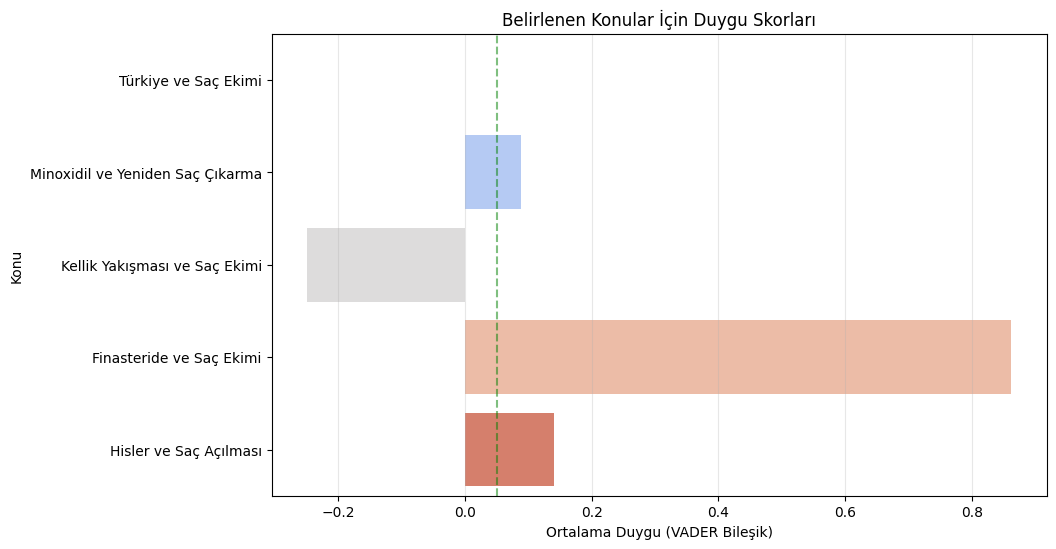

In [90]:
#Son olarak da konuları görselleştirip ortalama skora göre oranlarını inceliyoruz.
plt.figure(figsize=(10, 6))
sns.barplot(data=topic_sentiment, x='Ort_Duygu', y='Konu_Aciklamasi', hue='Konu_Aciklamasi', palette='coolwarm', legend=False)
plt.title('Belirlenen Konular İçin Duygu Skorları')
plt.xlabel('Ortalama Duygu (VADER Bileşik)')
plt.ylabel('Konu')
plt.axvline(0.05, color='green', linestyle='--', alpha=0.5)
plt.grid(axis='x', alpha=0.3)
plt.show()